In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import kagglehub

# download diabetes dataset from Kaggle
path = kagglehub.dataset_download("brandao/diabetes")

In [69]:
df = pd.read_csv(f"{path}/diabetic_data.csv")
df.shape

(101766, 50)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [71]:
print('Percentage of null weight values:', round(df[df['weight'] == '?']['weight'].count() /
    df.shape[0] * 100, 2)
)

print('Percentage of null race values:', round(df[df['race'] == '?']['race'].count() /
      df.shape[0] * 100, 2)
)

Percentage of null weight values: 96.86
Percentage of null race values: 2.23


In [72]:
# missing values, max_glu_serum and A1Cresult were not tested
# on those patients, not data entry error
df.isna().sum().sort_values(ascending=False)

max_glu_serum               96420
A1Cresult                   84748
encounter_id                    0
nateglinide                     0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
tolazamide                      0
examide                         0
citoglipton                     0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
chlorpropamide                  0
repaglinide                     0
patient_nbr                     0
medical_specialty               0
race          

In [73]:
# instead of NA, we have '?' for missing values
# i can drop weight - other categories missing values have enough
(
    (df[df == '?'].count().sort_values(ascending=False) * 100) /
    df.shape[0]
)

weight                      96.858479
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
encounter_id                 0.000000
tolazamide                   0.000000
glyburide                    0.000000
tolbutamide                  0.000000
pioglitazone                 0.000000
rosiglitazone                0.000000
acarbose                     0.000000
miglitol                     0.000000
troglitazone                 0.000000
citoglipton                  0.000000
examide                      0.000000
acetohexamide                0.000000
insulin                      0.000000
glyburide-metformin          0.000000
glipizide-metformin          0.000000
glimepiride-pioglitazone     0.000000
metformin-rosiglitazone      0.000000
metformin-pioglitazone       0.000000
change                       0.000000
diabetesMed 

In [74]:
df = df.drop(columns=['weight'])

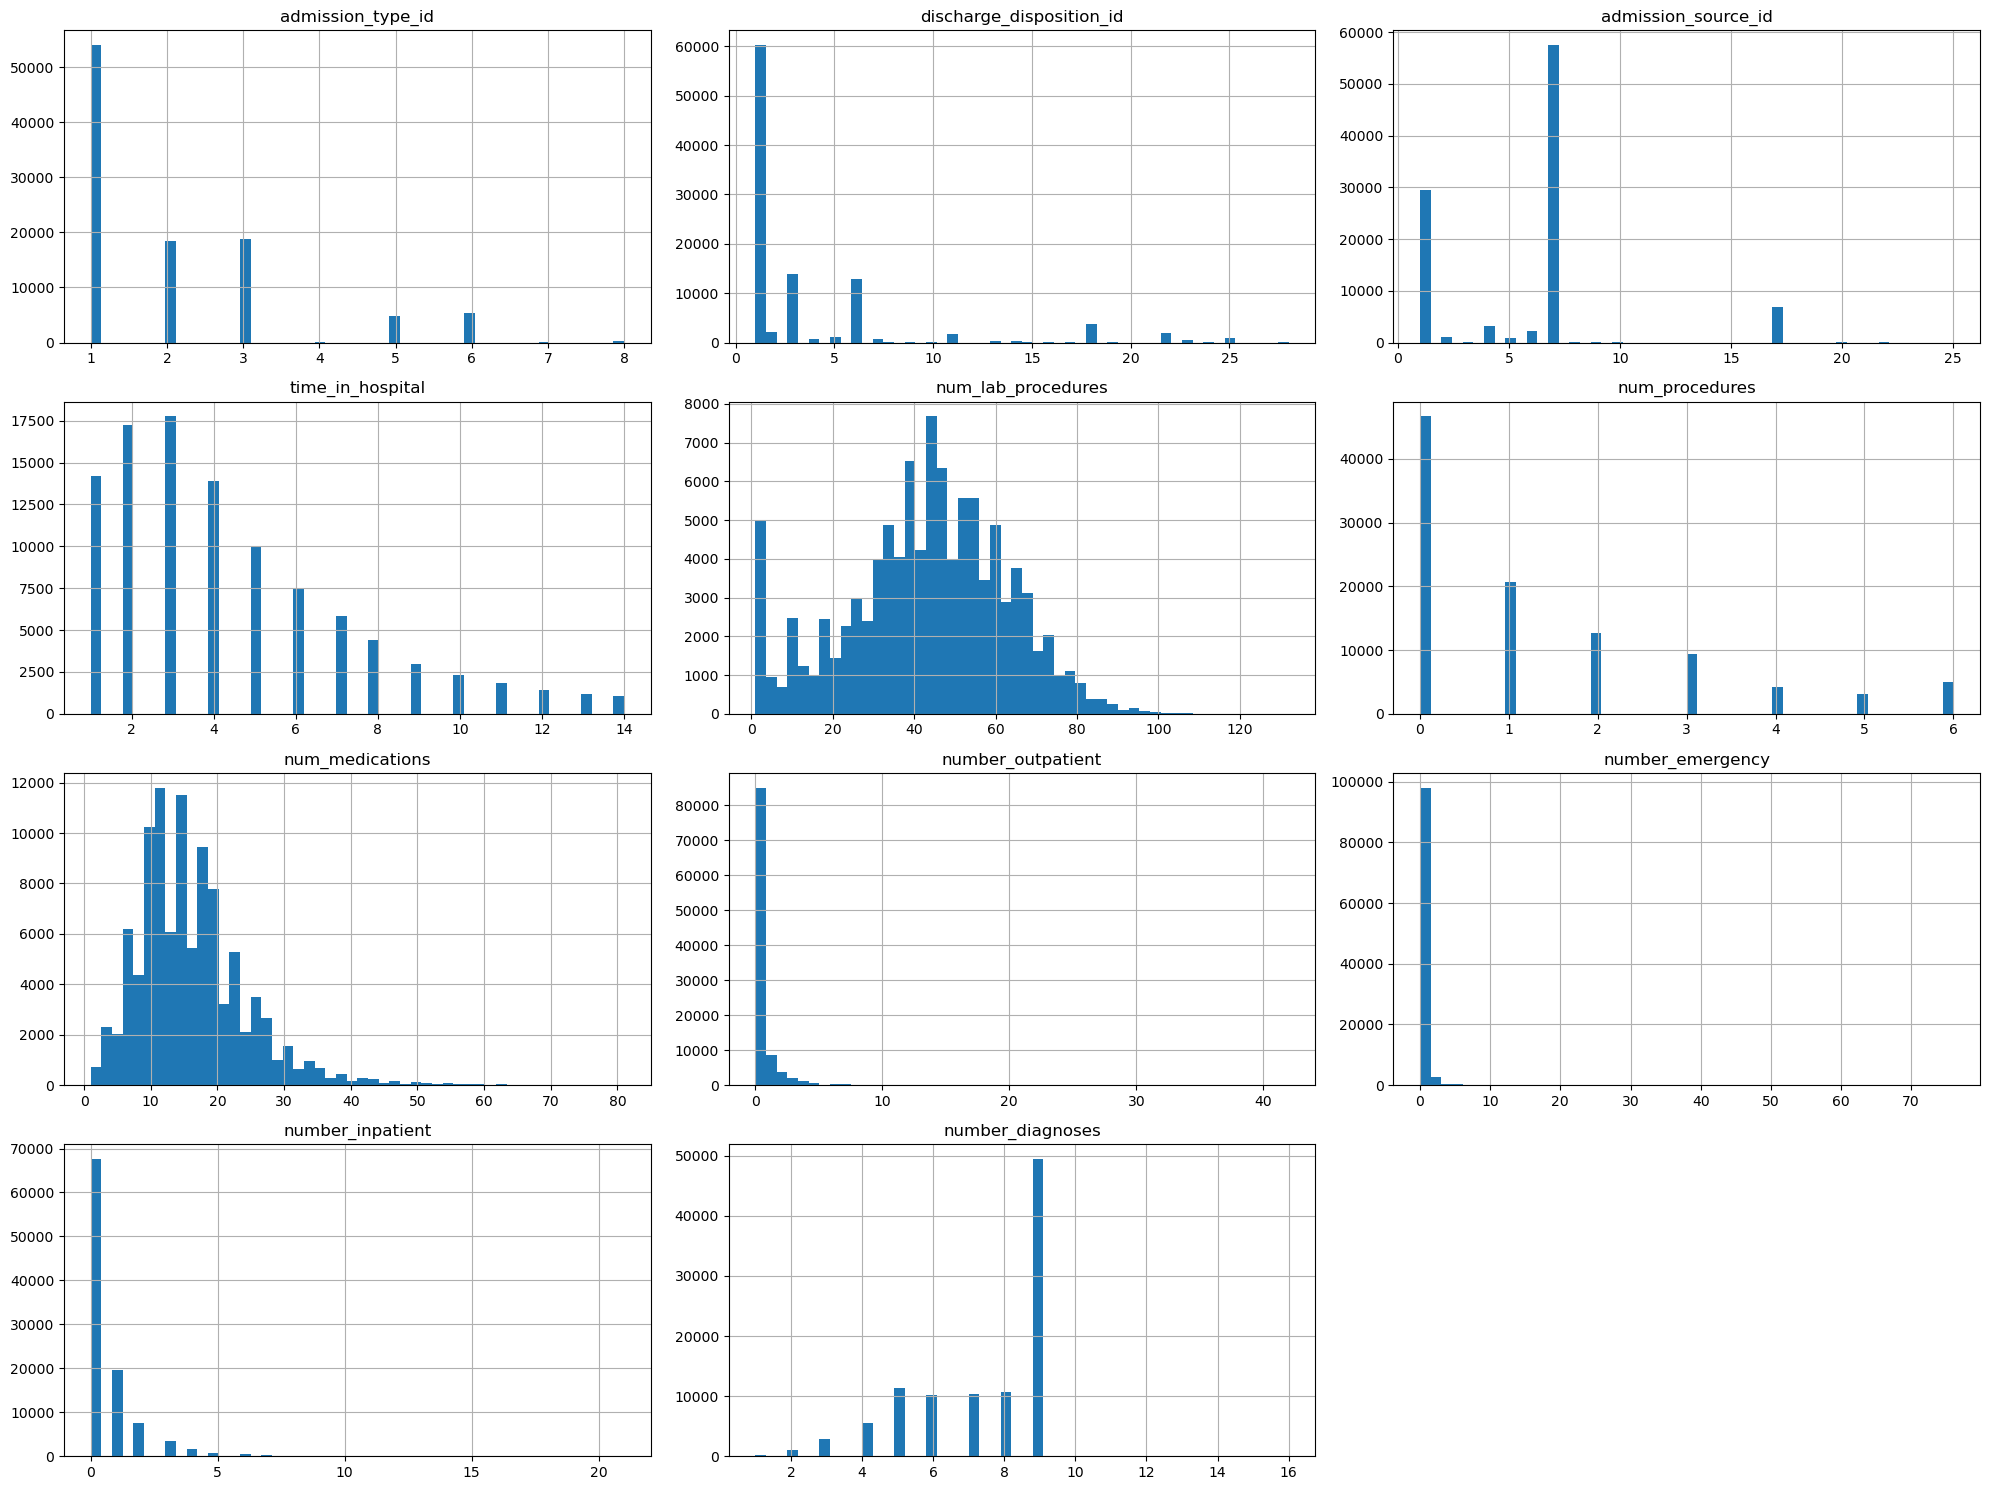

In [75]:
# histograms of numeric features
df.drop(columns = ['encounter_id','patient_nbr']).hist(figsize=(20, 15), bins = 50)
plt.tight_layout()
plt.show()

In [76]:
# number of patients readmitted vs not readmitted
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

,num_lab_procedures,num_procedures,num_medications,time_in_hospital
readmitted,,,,
<30,44.226028,1.280884,16.903143,4.768249
>30,43.836601,1.249599,16.282768,4.495541
NO,42.381598,1.410305,15.670367,4.254429


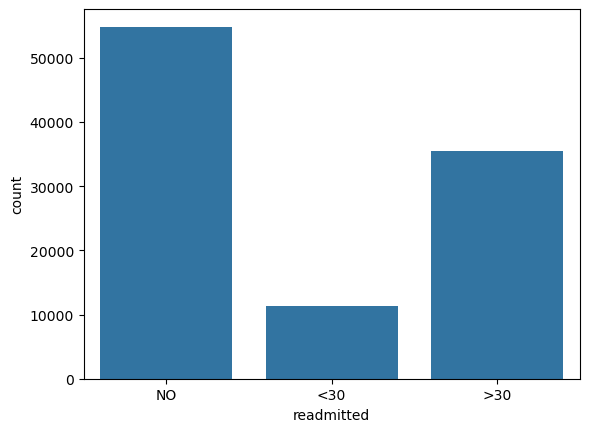

In [77]:
# check for class imbalance
sns.countplot(data = df,
              x = 'readmitted',
              order = ['NO', '<30', '>30'])
df.groupby(by = 'readmitted').agg({'num_lab_procedures': 'mean',
                                   'num_procedures': 'mean',
                                   'num_medications': 'mean',
                                   'time_in_hospital': 'mean'})

<Axes: xlabel='readmitted', ylabel='proportion'>

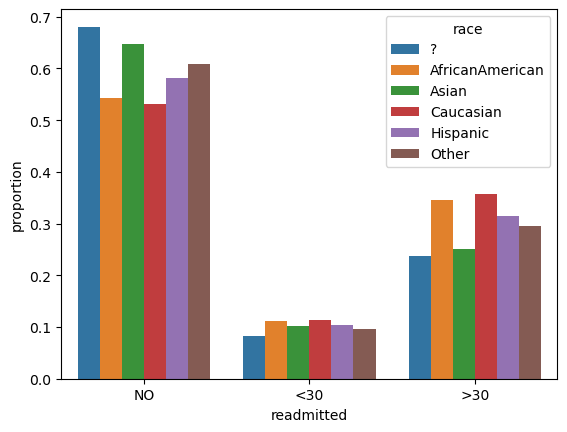

In [78]:
# readmission rates by race
prop_df = (
    df.groupby(by = ['race', 'readmitted'])
    .size()
    .reset_index(name='count')
)
prop_df['proportion'] = prop_df.groupby('race')['count'].transform(lambda x: x / x.sum())

# barplot of results
sns.barplot(data = prop_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'race',
            order = ['NO', '<30', '>30'])

<Axes: xlabel='readmitted', ylabel='proportion'>

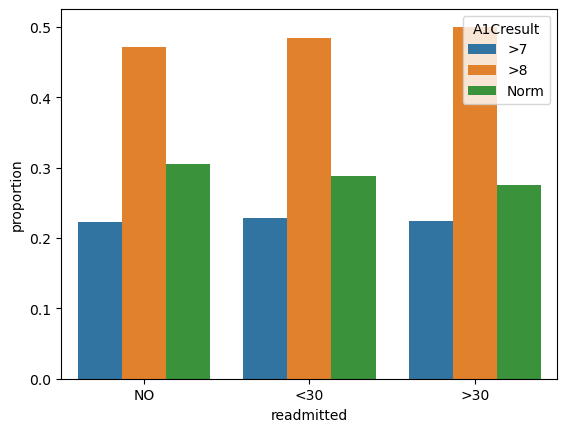

In [79]:
# A1c results by readmission status
A1C_df = (df.groupby(by = ['A1Cresult', 'readmitted'])
     .size()
     .reset_index(name='count')
)
A1C_df['proportion'] = A1C_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())

sns.barplot(data = A1C_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'A1Cresult',
            errorbar = 'se',
            order = ['NO', '<30', '>30'])

<Axes: xlabel='readmitted', ylabel='proportion'>

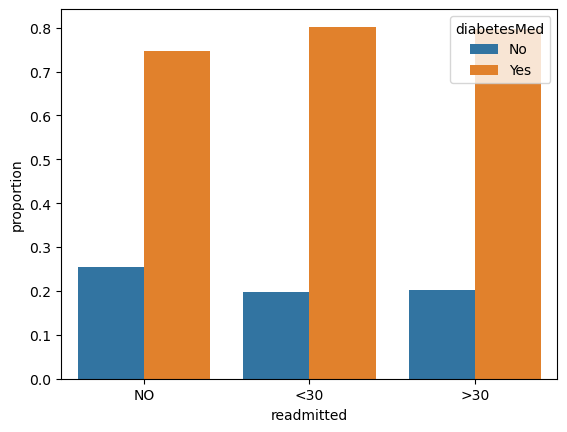

In [80]:
# diabetes medications by readmission status
diabet_df = (df.groupby(by = ['diabetesMed', 'readmitted'])
     .size()
     .reset_index(name='count')
)
diabet_df['proportion'] = diabet_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())


sns.barplot(data = diabet_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'diabetesMed',
            order = ['NO', '<30', '>30'])

<Axes: xlabel='readmitted', ylabel='proportion'>

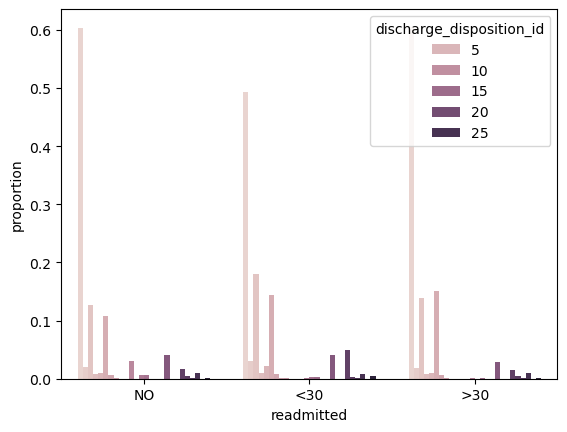

In [81]:
# discharge disposition by readmission status
discharge_df = (df.groupby(by = ['discharge_disposition_id', 'readmitted'])
     .size()
     .reset_index(name='count')
)
discharge_df['proportion'] = discharge_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = discharge_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'discharge_disposition_id',
            errorbar = 'se',
            order = ['NO', '<30', '>30'])

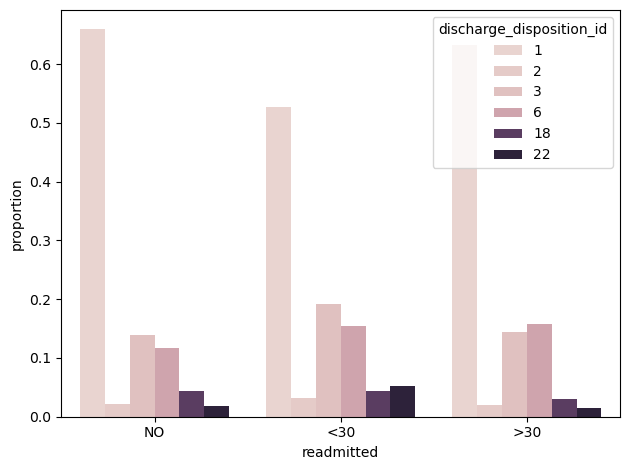

In [82]:
top_dispositions = df['discharge_disposition_id'].value_counts().head(6).index
df_filtered = df[df['discharge_disposition_id'].isin(top_dispositions)]

discharge_df = (df_filtered.groupby(by = ['discharge_disposition_id', 'readmitted'])
     .size()
     .reset_index(name='count')
)
discharge_df['proportion'] = discharge_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = discharge_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'discharge_disposition_id',
            errorbar = 'se',
            order = ['NO', '<30', '>30'])
plt.tight_layout()

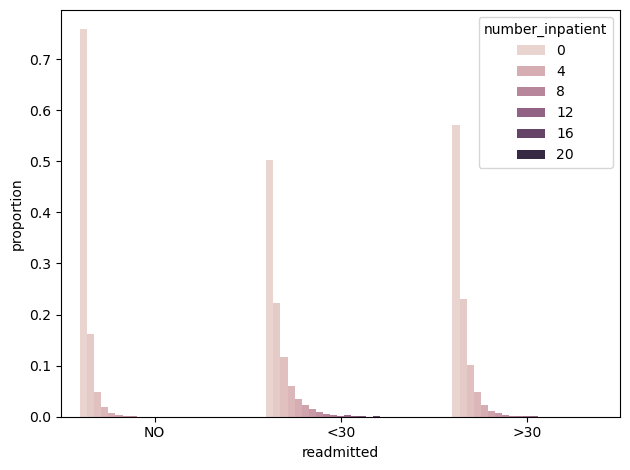

In [83]:
# prior inpatient visits by readmission status
prior_inpatient_df = (df.groupby(by = ['number_inpatient', 'readmitted'])
     .size()
     .reset_index(name='count')
)
prior_inpatient_df['proportion'] = prior_inpatient_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = prior_inpatient_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'number_inpatient',
            errorbar = 'se',
            order = ['NO', '<30', '>30'])
plt.tight_layout()

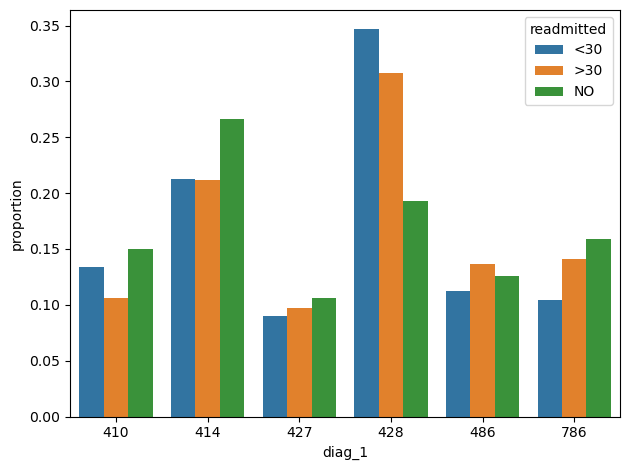

In [84]:
# first diagnosis by readmission status
top_diagnoses = df['diag_1'].value_counts().head(6).index
df_filtered = df[df['diag_1'].isin(top_diagnoses)]
diagnosis_df = (df_filtered.groupby(by = ['diag_1', 'readmitted'])
     .size()
     .reset_index(name='count')
)
diagnosis_df['proportion'] = diagnosis_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = diagnosis_df,
            x = 'diag_1',
            y = 'proportion',
            hue = 'readmitted',
            errorbar = 'se')
plt.tight_layout()


In [85]:
# primary diagnosis of ICD-9 code 250 is miswritten as 250.00, 250.01, etc. 
# I want to check how many patients have diabetes as primary diagnosis
x = 0
for diag in df['diag_1']:
    if '.' in diag:
        if diag.partition('.')[0] == '250':
            x += 1
print (x)

# fix diabetes code for primary, secondary, and tertiary diagnoses
df['diag_1'] = [diag.partition('.')[0] for diag in df['diag_1']]
df['diag_2'] = [diag.partition('.')[0] for diag in df['diag_2']]
df['diag_3'] = [diag.partition('.')[0] for diag in df['diag_3']]

8522


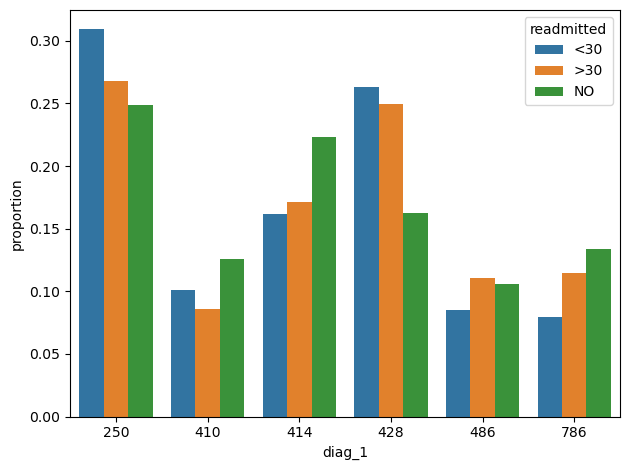

In [86]:
# re-run diagnosis by readmission status with fixed diabetes codes
top_diagnoses = df['diag_1'].value_counts().head(6).index
df_filtered = df[df['diag_1'].isin(top_diagnoses)]
diagnosis_df = (df_filtered.groupby(by = ['diag_1', 'readmitted'])
     .size()
     .reset_index(name='count')
)

diagnosis_df['proportion'] = diagnosis_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = diagnosis_df,
            x = 'diag_1',
            y = 'proportion',
            hue = 'readmitted',
            errorbar = 'se')
plt.tight_layout()

In [87]:
# add ICD-9 descriptions to the dataset using crosswalk file
# fix crosswalk file before merging - some codes have letters preceding, most codes are not written the same was as in the dataset
# check which codes in the dataset are not in the crosswalk file

icd9_crosswalk = pd.read_csv("data/icd9_crosswalk.csv")
icd9_crosswalk['ICD9'] = icd9_crosswalk['ICD9'].str[:3]
icd9_crosswalk_deduped = icd9_crosswalk.drop_duplicates(subset='ICD9', keep='last')

# manually fix relevant code descriptions since many come up multiple times in the crosswalk file with different descriptions
icd9_crosswalk_deduped['Description'] = icd9_crosswalk_deduped['Description'].replace({'DMI unspf uncntrld': 'Diabetes mellitus',
                                                                                       'AMI NOS, subsequent': 'Acute myocardial infarction',
                                                                                       'Chr ischemic hrt dis NOS': 'Chronic ischemic heart disease',
                                                                                       'Heart failure NOS': 'Heart failure',
                                                                                       'Pneumonia, organism NOS': 'Pneumonia',
                                                                                       'Resp sys/chest symp NEC': 'Respiratory symptoms',
                                                                                       'Hypertension NOS': 'Hypertension',
                                                                                       'Electrolyt/fluid dis NEC': 'Electrolyte/fluid disorders',
                                                                                       'Cardiac dysrhythmia NOS': 'Cardiac dysrhythmias',
                                                                                       'Chr airway obstruct NEC': 'Chronic airway obstruction'})


# merge crosswalk to descriptions of the primary, secondary, and tertiary diagnoses
df = df.merge(icd9_crosswalk_deduped, how = 'left', left_on = 'diag_1', right_on = 'ICD9')
df = df.rename(columns = {'Description': 'diag_1_desc'})
df = df.merge(icd9_crosswalk_deduped, how = 'left', left_on = 'diag_2', right_on = 'ICD9')
df = df.rename(columns = {'Description': 'diag_2_desc'})
df = df.merge(icd9_crosswalk_deduped, how = 'left', left_on = 'diag_3', right_on = 'ICD9')
df = df.rename(columns = {'Description': 'diag_3_desc'})
df[['diag_1','diag_1_desc','diag_2','diag_2_desc','diag_3','diag_3_desc']].head(20)

/var/folders/pp/9q27z0251bz7mk8h4tmcwh6h0000gn/T/ipykernel_23596/1271239875.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  icd9_crosswalk_deduped['Description'] = icd9_crosswalk_deduped['Description'].replace({'DMI unspf uncntrld': 'Diabetes mellitus',


,diag_1,diag_1_desc,diag_2,diag_2_desc,diag_3,diag_3_desc
0,250,Diabetes mellitus,?,NaN,?,NaN
1,276,Electrolyte/fluid disorders,250,Diabetes mellitus,255,Adrenal disorder NOS
2,648,Oth curr cond-postpartum,250,Diabetes mellitus,V27,Outcome of delivery NOS
3,8,NaN,250,Diabetes mellitus,403,Hyp kid NOS w cr kid V
4,197,Sec mal neo GI NEC,157,Malig neo pancreas NOS,250,Diabetes mellitus
5,414,Chronic ischemic heart disease,411,Ac ischemic hrt dis NEC,250,Diabetes mellitus
6,414,Chronic ischemic heart disease,411,Ac ischemic hrt dis NEC,V45,Post-proc states NEC
7,428,Heart failure,492,Emphysema NEC,250,Diabetes mellitus
8,398,Rheumatic heart dis NEC,427,Cardiac dysrhythmias,38,Salmonella infection NEC
9,434,Crbl art ocl NOS w infrc,198,Secondary malig neo NEC,486,Pneumonia


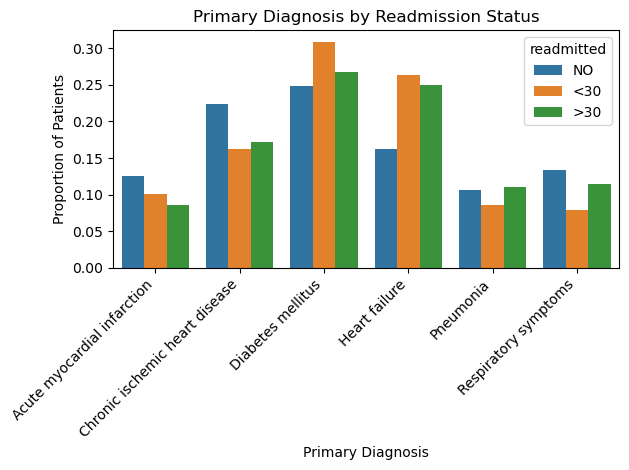

In [88]:
# add descriptions to diagnosis by readmission status plot
top_diagnoses_1 = df['diag_1_desc'].value_counts().head(6).index
df_filtered = df[df['diag_1_desc'].isin(top_diagnoses_1)]
diagnosis_1_df = (df_filtered.groupby(by = ['diag_1_desc', 'readmitted'])
     .size()
     .reset_index(name='count')
)
# calculate proportions for each readmission status to plot on the same graph
diagnosis_1_df['proportion'] = diagnosis_1_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())

sns.barplot(data = diagnosis_1_df,
            x = 'diag_1_desc',
            y = 'proportion',
            hue = 'readmitted',
            hue_order = ['NO', '<30', '>30'],
            errorbar = 'se')
plt.xticks(rotation = 45, ha = 'right')
plt.title('Primary Diagnosis by Readmission Status')
plt.xlabel('Primary Diagnosis')
plt.ylabel('Proportion of Patients')
plt.tight_layout()

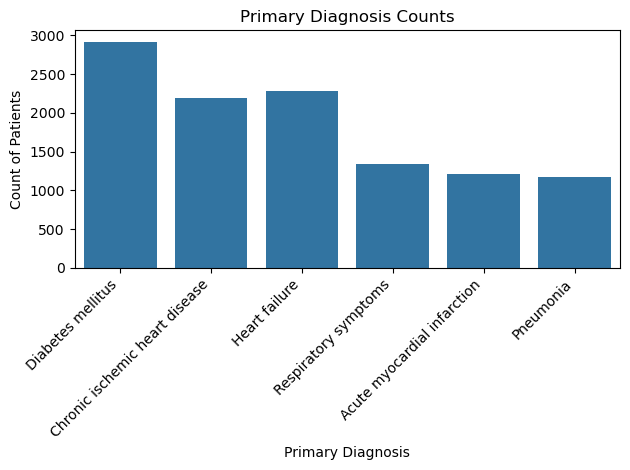

In [89]:
# primary diagnosis counts
sns.barplot(data = diagnosis_1_df.sort_values(by = 'count', ascending = False).reset_index(drop=True),
            x = 'diag_1_desc',
            y = 'count',
            errorbar = None)
            
plt.xticks(rotation = 45, ha = 'right')
plt.title('Primary Diagnosis Counts')
plt.xlabel('Primary Diagnosis')
plt.ylabel('Count of Patients')
plt.tight_layout()

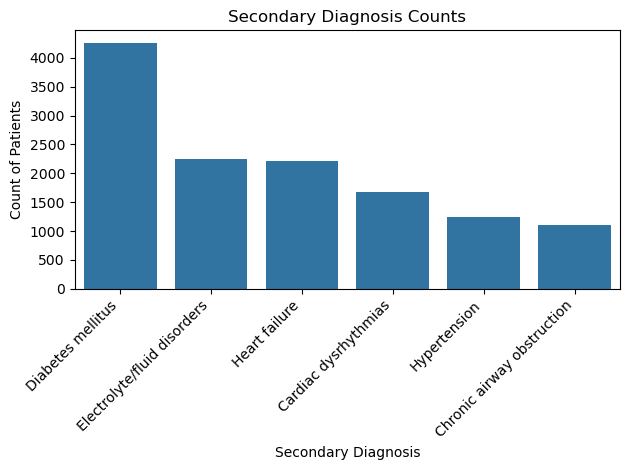

In [90]:
# secondary diagnosis counts
top_diagnoses_2 = df['diag_2_desc'].value_counts().head(6).index
df_filtered = df[df['diag_2_desc'].isin(top_diagnoses_2)]
diagnosis_2_df = (df_filtered.groupby(by = ['diag_2_desc', 'readmitted'])
     .size()
     .reset_index(name='count')
)

sns.barplot(data = diagnosis_2_df.sort_values(by = 'count', ascending = False).reset_index(drop=True),
            x = 'diag_2_desc',
            y = 'count',
            errorbar = None)
plt.xticks(rotation = 45, ha = 'right')
plt.title('Secondary Diagnosis Counts')
plt.xlabel('Secondary Diagnosis')
plt.ylabel('Count of Patients')
plt.tight_layout()

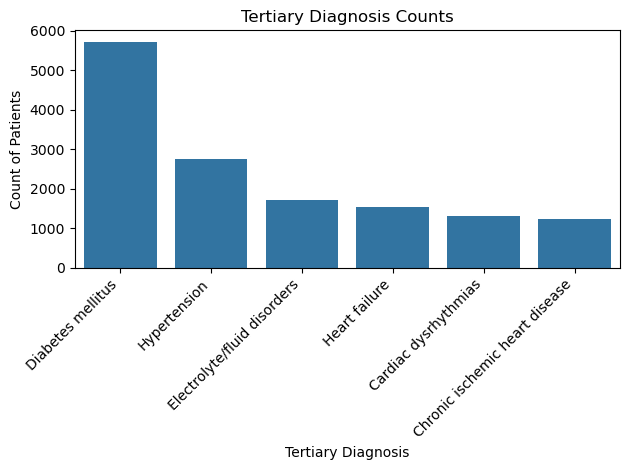

In [91]:
# tertiary diagnosis counts
top_diagnoses_3 = df['diag_3_desc'].value_counts().head(6).index
df_filtered = df[df['diag_3_desc'].isin(top_diagnoses_3)]
diagnosis_3_df = (df_filtered.groupby(by = ['diag_3_desc', 'readmitted'])
     .size()
     .reset_index(name='count')
)

sns.barplot(data = diagnosis_3_df.sort_values(by = 'count', ascending = False).reset_index(drop=True),
            x = 'diag_3_desc',
            y = 'count',
            errorbar = None)
plt.xticks(rotation = 45, ha = 'right')
plt.title('Tertiary Diagnosis Counts')
plt.xlabel('Tertiary Diagnosis')
plt.ylabel('Count of Patients')
plt.tight_layout()

/var/folders/pp/9q27z0251bz7mk8h4tmcwh6h0000gn/T/ipykernel_23596/389175703.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  readmit_rate = df.groupby(['diag_1','diag_1_desc']).apply(


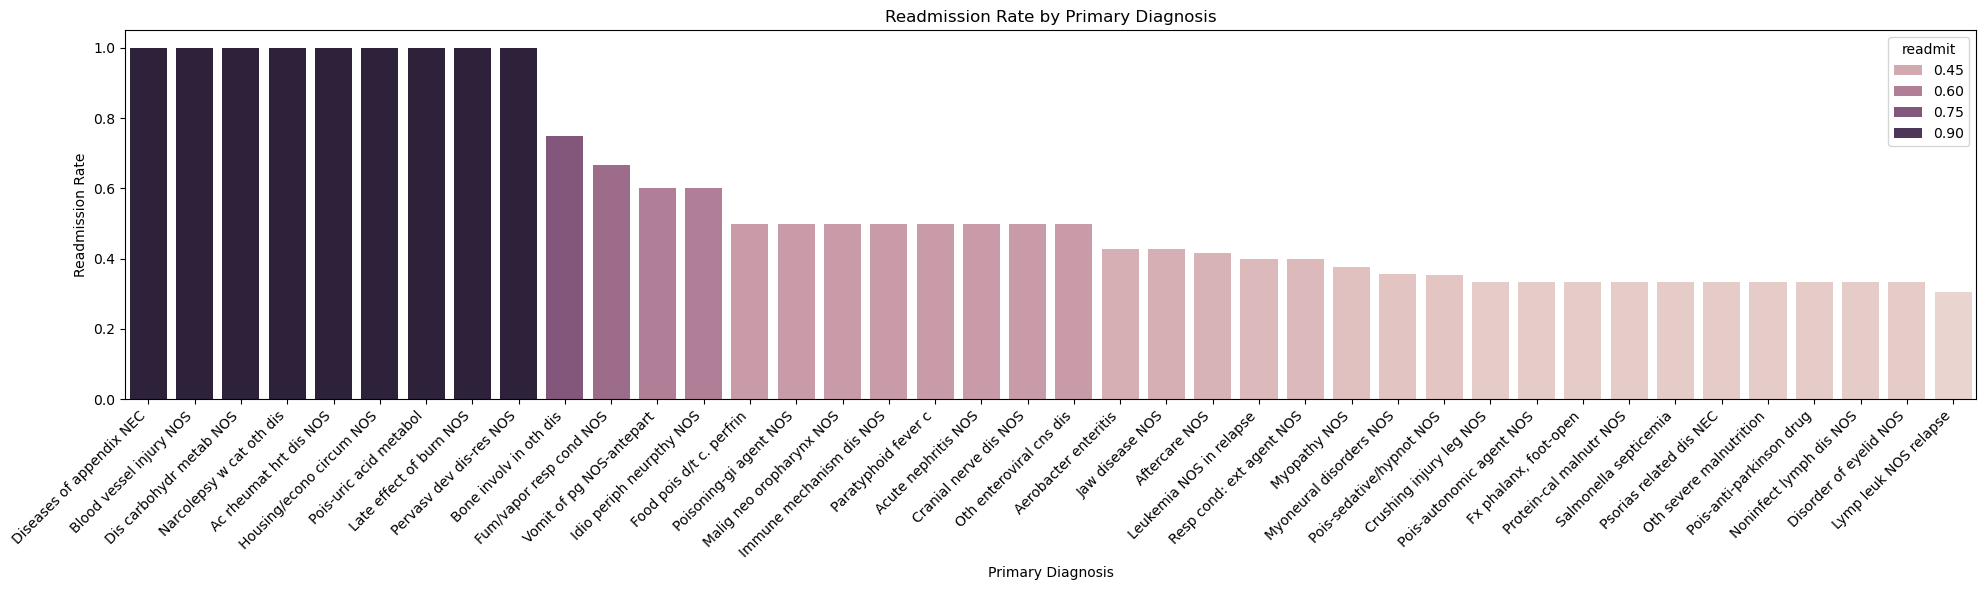

In [92]:
# readmission rates by primary diagnosis
readmit_rate = df.groupby(['diag_1','diag_1_desc']).apply(
    lambda x: (x['readmitted'] == '<30').sum() / len(x)
).sort_values(ascending=False).reset_index(name = 'readmit')

plt.figure(figsize=(20, 6))
sns.barplot(data = readmit_rate[:40],
            x = 'diag_1_desc',
            y = 'readmit',
            hue = 'readmit')

plt.xticks(rotation = 45, ha = 'right')
plt.title('Readmission Rate by Primary Diagnosis')
plt.xlabel('Primary Diagnosis')
plt.ylabel('Readmission Rate')
plt.tight_layout()

/var/folders/pp/9q27z0251bz7mk8h4tmcwh6h0000gn/T/ipykernel_23596/2701716753.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  readmit_rate = df[df['diag_1_desc'].isin(valid_diagnoses)].groupby('diag_1_desc').apply(


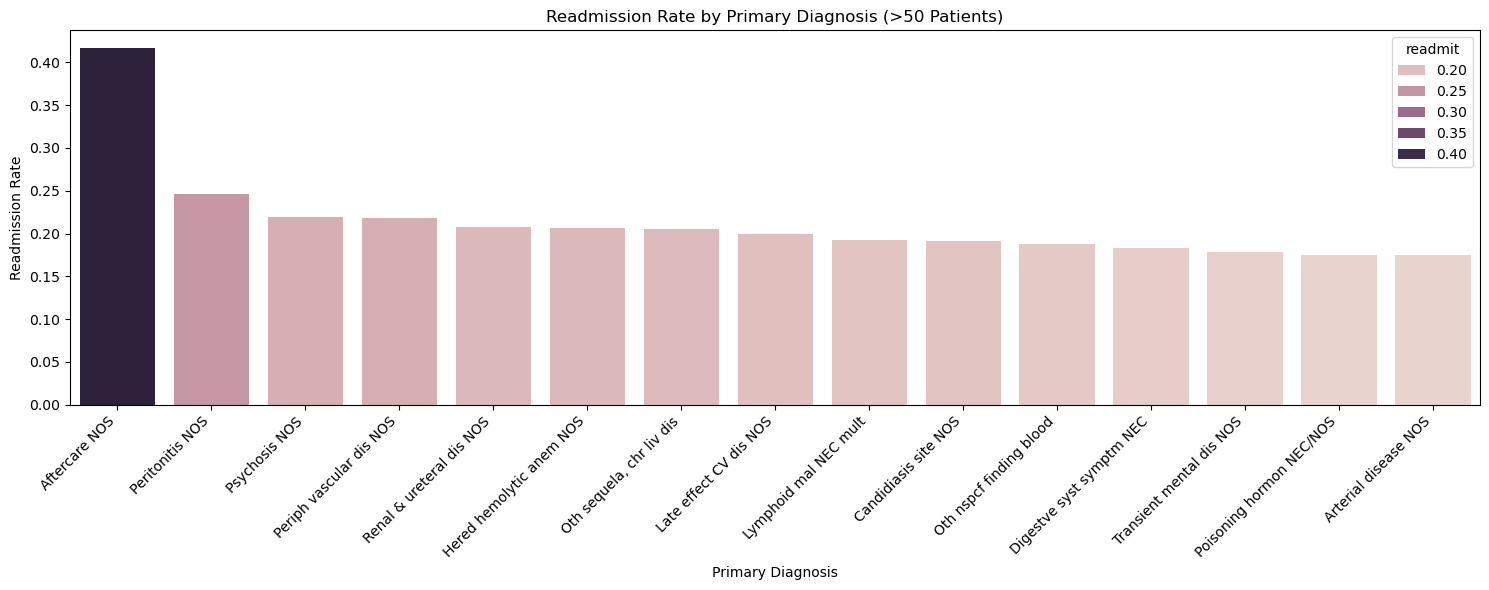

In [93]:
# filter to diagnoses with at least 50 patients to avoid small sample size issues
diagnosis_counts = df.groupby('diag_1_desc')['readmitted'].count()
valid_diagnoses = diagnosis_counts[diagnosis_counts >= 50].index

readmit_rate = df[df['diag_1_desc'].isin(valid_diagnoses)].groupby('diag_1_desc').apply(
    lambda x: (x['readmitted'] == '<30').sum() / len(x)
).sort_values(ascending=False).reset_index(name = 'readmit')

plt.figure(figsize=(15, 6))
sns.barplot(data = readmit_rate[:15],
            x = 'diag_1_desc',
            y = 'readmit',
            hue = 'readmit')

plt.xticks(rotation = 45, ha = 'right')
plt.title('Readmission Rate by Primary Diagnosis (>50 Patients)')
plt.xlabel('Primary Diagnosis')
plt.ylabel('Readmission Rate')
plt.tight_layout()

In [94]:
# looking at diabetes specifically
diabetes_df = df[df['diag_1_desc'] == 'Diabetes mellitus' ]


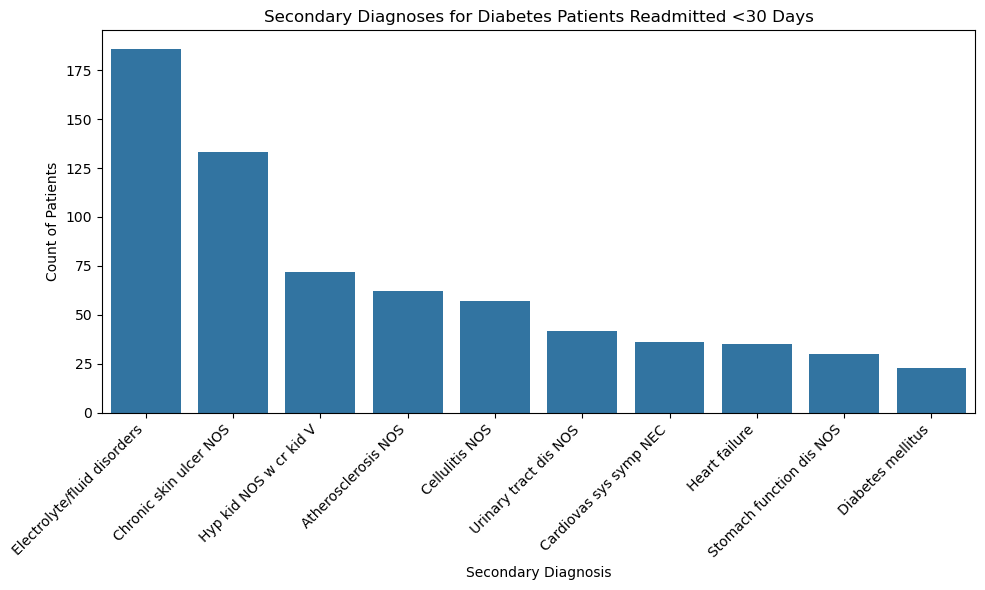

In [95]:
# secondary diagnoses for diabetes patients readmitted <30 days
diabetes_readmit = df[(df['diag_1_desc'] == 'Diabetes mellitus') & (df['readmitted'] == '<30')]

plt.figure(figsize=(10, 6))
sns.barplot(data = diabetes_readmit['diag_2_desc'].value_counts().head(10).reset_index(name = 'count'),
            x = 'diag_2_desc',
            y = 'count')
plt.xticks(rotation = 45, ha = 'right')
plt.title('Secondary Diagnoses for Diabetes Patients Readmitted <30 Days')
plt.xlabel('Secondary Diagnosis')
plt.ylabel('Count of Patients')
plt.tight_layout()

In [96]:
# percent of diabetes patients missing A1C results
print('Percent of diabetes patients missing A1C results:', round((diabetes_df['A1Cresult'].isna().sum() / diabetes_df.shape[0] * 100), 2))
print('Percent of diabetes patients readmitted <30 days missing A1C results:', round((diabetes_readmit['A1Cresult'].isna().sum() / diabetes_readmit.shape[0] * 100), 2))

# run t-test on results
import scipy.stats as stats
stats.ttest_ind(diabetes_df['A1Cresult'].isna(), diabetes_readmit['A1Cresult'].isna(), equal_var = False)

Percent of diabetes patients missing A1C results: 68.53
Percent of diabetes patients readmitted <30 days missing A1C results: 76.87


TtestResult(statistic=-6.197179168780188, pvalue=7.391737302587408e-10, df=1516.8012576880535)

In [97]:

A1C_results

NameError: name 'A1C_results' is not defined

/var/folders/pp/9q27z0251bz7mk8h4tmcwh6h0000gn/T/ipykernel_46425/2764056662.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  A1C_results['A1Cresult'].fillna('Missing', inplace = True)


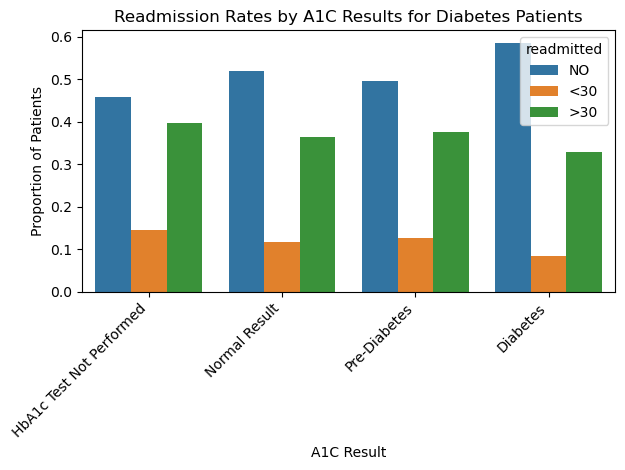

In [ ]:
# readmittance rates by A1C results for diabetes patients
A1C_results = diabetes_df.groupby(by = ['A1Cresult', 'readmitted'], dropna = False).size().reset_index(name = 'count')
A1C_results['A1Cresult'].fillna('Missing', inplace = True)
A1C_results['proportion'] = A1C_results.groupby('A1Cresult')['count'].transform(lambda x: x / x.sum())


sns.barplot(data = A1C_results,
            x = 'A1Cresult',
            y = 'proportion',
            hue = 'readmitted',
            hue_order = ['NO', '<30', '>30'],
            order = ['Missing', 'Norm','>7', '>8'])

plt.title('Readmission Rates by A1C Results for Diabetes Patients')
plt.xlabel('A1C Result')
plt.xticks([0, 1, 2, 3],['HbA1c Test Not Performed', 'Normal Result', 'Pre-Diabetes', 'Diabetes'],
           rotation = 45, ha = 'right')
plt.ylabel('Proportion of Patients')
plt.tight_layout()

In [ ]:
# key data for Tableau dashboard
print('total patients:', df.shape[0])
print('30-day readmission percentage:', round((df[df['readmitted'] == '<30']['readmitted'].count() / df.shape[0] * 100), 2))
print('average LOS in days:', round(df['time_in_hospital'].mean(), 2))
print('average number of medications per patient:', round(df['num_medications'].mean(), 2))

total patients: 101766
30-day readmission percentage: 11.16
average LOS in days: 4.4
average number of medications per patient: 16.02


In [ ]:
# export cleaned dataset for Tableau dashboard
df.to_csv('data/diabetes_cleaned.csv', index = False)

In [ ]:
df[['A1Cresult', 'change', 'insulin', 'num_medications', 'readmitted']].head()


,A1Cresult,change,insulin,num_medications,readmitted
0,NaN,No,No,1,NO
1,NaN,Ch,Up,18,>30
2,NaN,No,No,13,NO
3,NaN,Ch,Up,16,NO
4,NaN,Ch,Steady,8,NO


In [100]:
# make new csv for clinical data analysis in Tableau
df['change'] = df['change'].map({'No': 'No Change', 'Ch': 'Changed'})


clinical_df = df[df['diag_1_desc'] == 'Diabetes mellitus'][['A1Cresult', 'change', 'insulin', 'num_medications', 'readmitted']].copy()
clinical_df['A1Cresult'] = clinical_df['A1Cresult'].fillna('Missing')
clinical_df['change'] = clinical_df['change'].map({'No': 'No Change', 'Ch': 'Changed'})

clinical_df.to_csv('data/clinical_factors.csv', index=False)

In [102]:
clinical_df.head()

,A1Cresult,change,insulin,num_medications,readmitted
0,Missing,NaN,No,1,NO
10,Missing,NaN,Steady,17,>30
52,Missing,NaN,Steady,17,>30
56,Missing,NaN,Steady,19,>30
60,Missing,NaN,Steady,15,>30
